<p align="center">
  <br/>
    <a href="https://pdf-redaction.com/" target="_blank"><img alt="PDF Redaction"
    src="https://pdf-redaction.com/images/pdf-redaction-logo.svg" width="450" style="max-width: 100%;"></a>
  <br/>
</p>

<p align="center">
    <i>Secure Your PDFs with AI-powered Redaction</i>
</p>

<p align="center">
    <a target="_blank" href="https://colab.research.google.com/github/StabRise/pdf-redaction-api/blob/main/jupyter/PDF-Redaction-API.ipynb">
      <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://github.com/stabrise/spark-pdf/blob/main/LICENSE"><img alt="GitHub" src="https://img.shields.io/github/license/stabrise/spark-pdf.svg?color=blue"></a>
    <a href="https://stabrise.com"><img alt="StabRise" src="https://img.shields.io/badge/powered%20by-StabRise-orange.svg?style=flat&colorA=E1523D&colorB=blue"/>
    </a>
</p>

# Example of using PDF Redaction API

**Source**: [https://github.com/StabRise/pdf-redaction-api](https://github.com/StabRise/pdf-redaction-api)

[Swagger API documentation](https://stabrise-com--pdf-redaction-api-wrapper.modal.run/api/docs)

Web UI: [https://pdf-redaction.com](https://pdf-redaction.com)

For generate API Key please go to the: [https://pdf-redaction.com/apikeys/](https://pdf-redaction.com/apikeys/)

For check usage: [https://pdf-redaction.com/apikeys/usage/](https://pdf-redaction.com/apikeys/usage/)

Put API Key to the env variable `PDF_REDACTION_API_KEY` or to `.env` file.

## Limitations for free version
* 1 page per request
* 50 Free requests per month
* 5 requests per minute


## Installing dependencies for displaying PDF files

In [ ]:
!apt-get install poppler-utils

In [ ]:
%pip install requests pdf2image pillow python-dotenv

## Downloading example PDF files

In [23]:
!wget https://raw.githubusercontent.com/StabRise/pdf-redaction-api/refs/heads/main/examples/pdfs/sample_document_en.pdf

--2025-06-06 06:57:33--  https://raw.githubusercontent.com/StabRise/pdf-redaction-api/refs/heads/main/examples/pdfs/sample_document_en.pdf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1112179 (1.1M) [application/octet-stream]
Saving to: ‘sample_document_en.pdf.1’

sample_document_en. 100%[===================>]   1.06M  --.-KB/s    in 0.09s   

2025-06-06 06:57:34 (11.2 MB/s) - ‘sample_document_en.pdf.1’ saved [1112179/1112179]



# Display original PDF

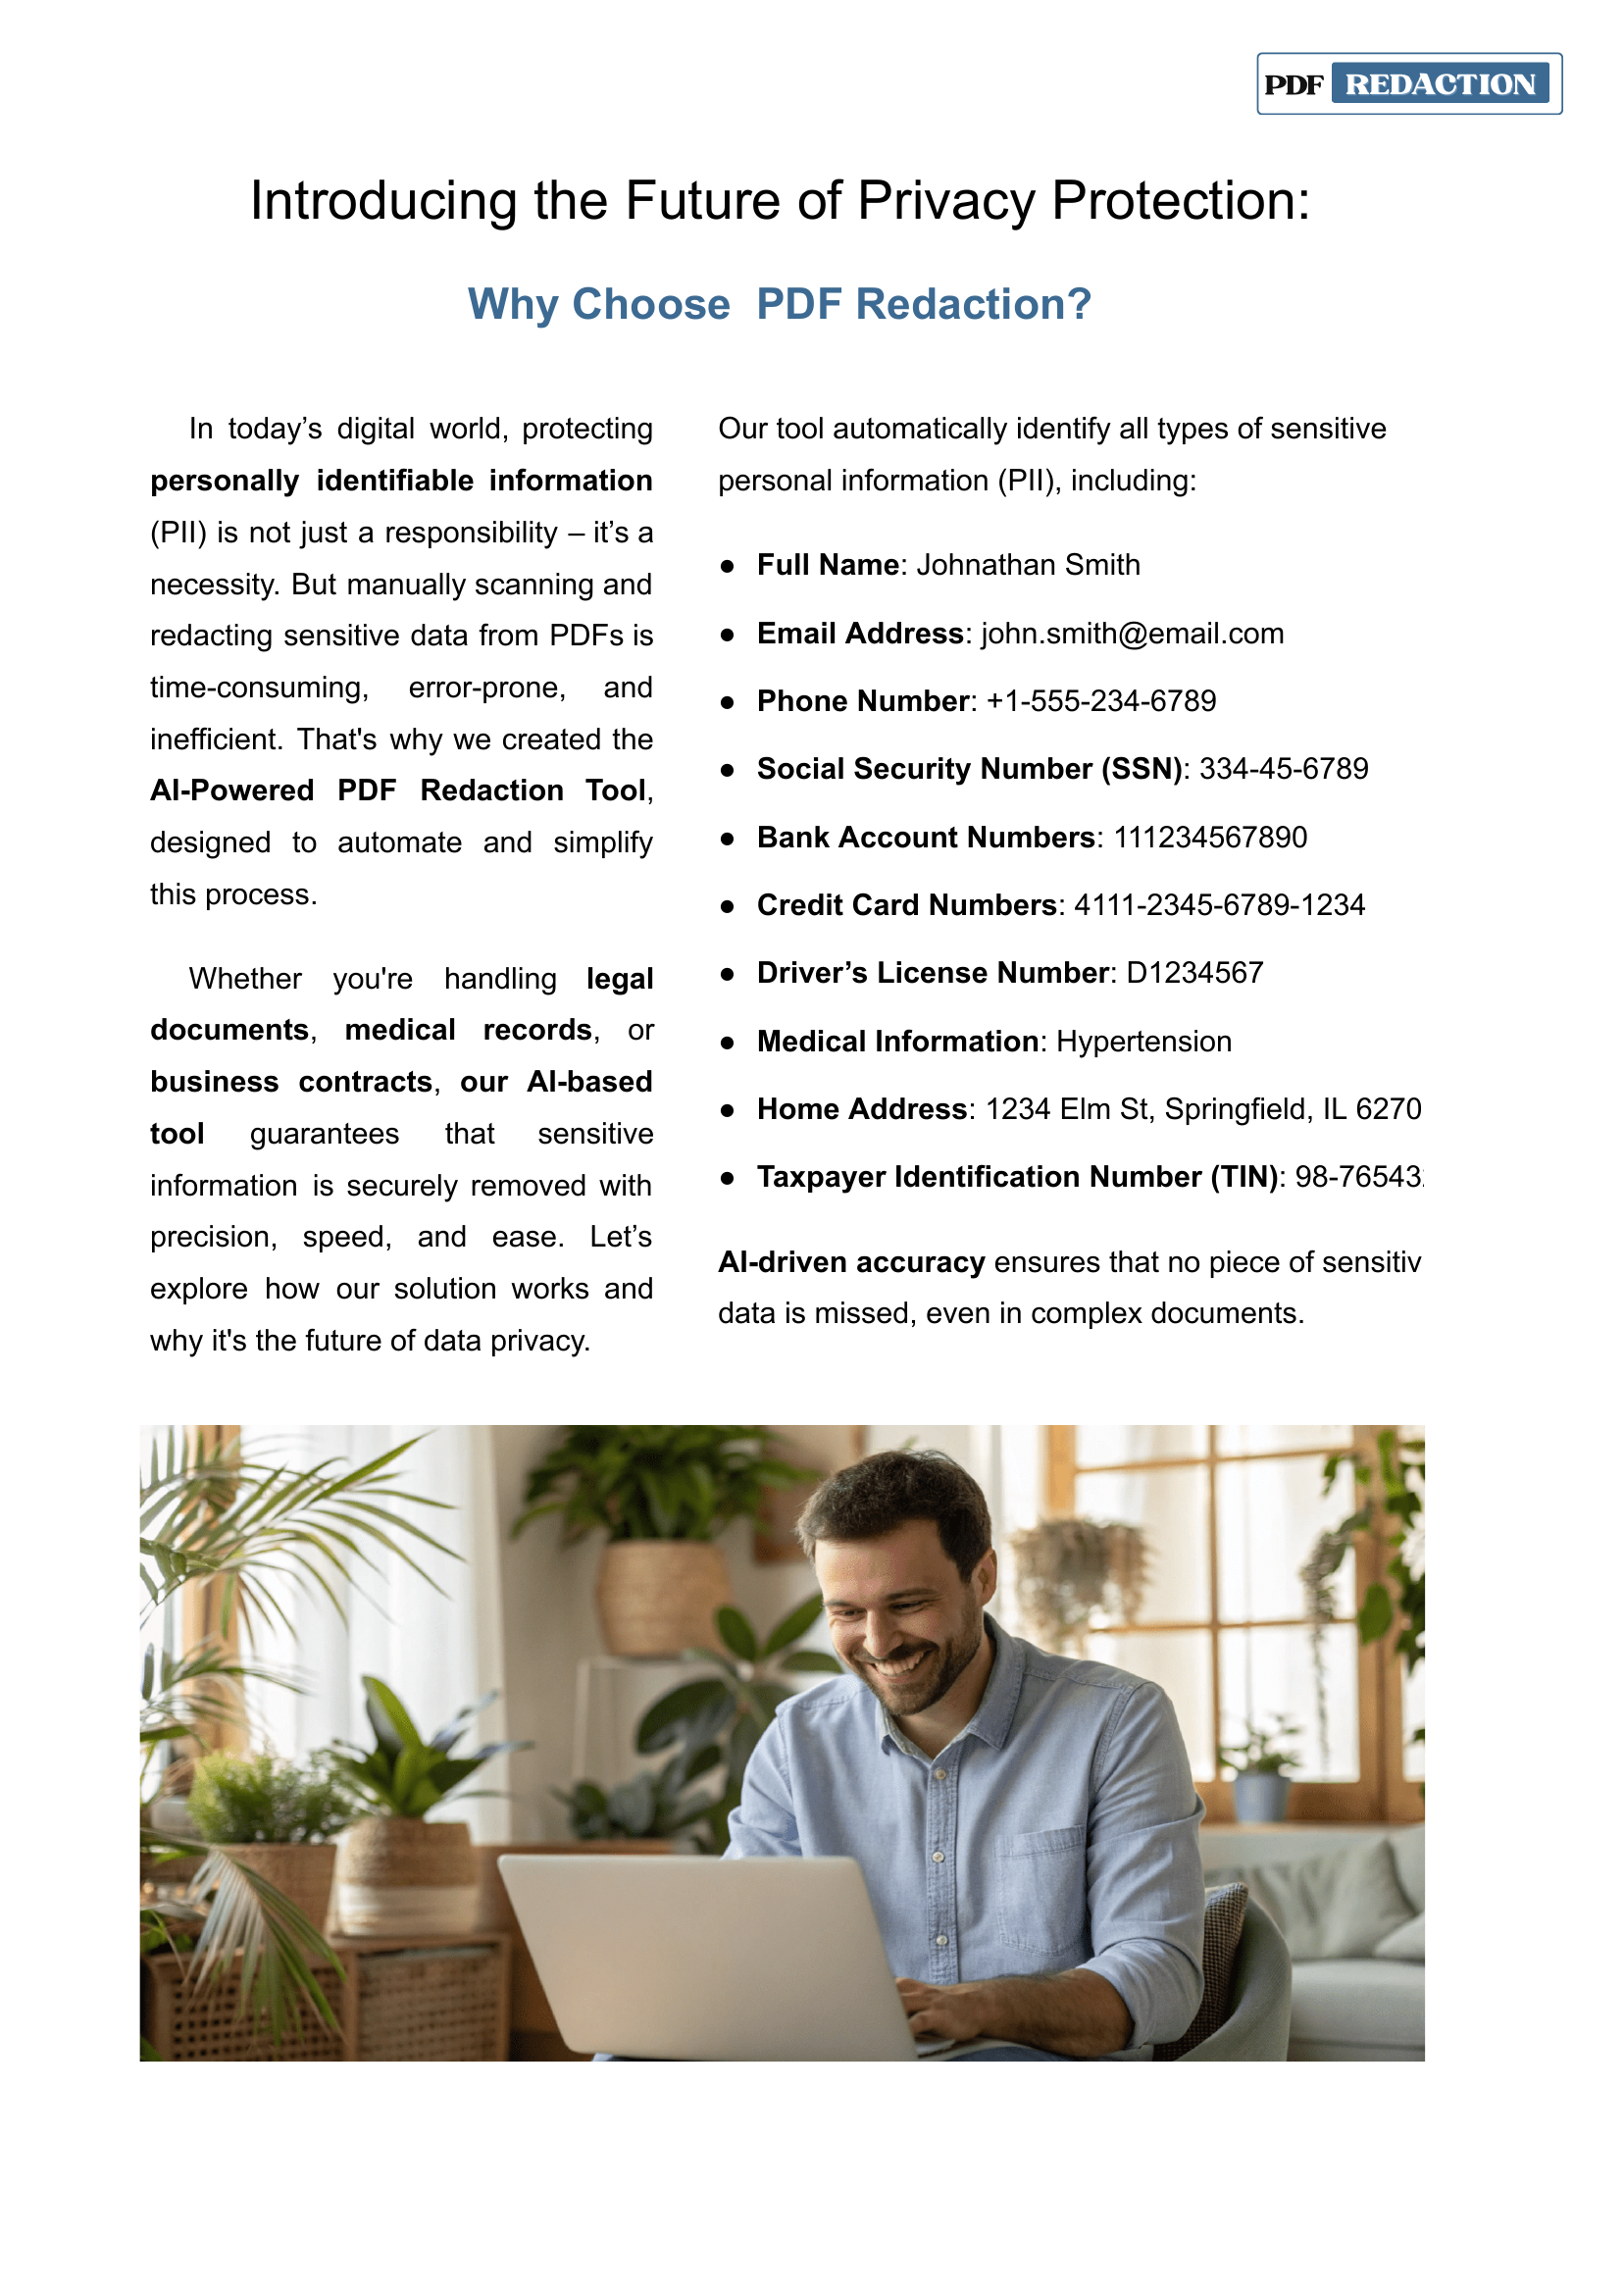

In [2]:
from pdf2image import convert_from_path
from IPython.display import display

# File path to your PDF (replace with your actual file path)
file_path = "./sample_document_en.pdf"
# or use local file from example folder
#file_path = "../examples/pdfs/sample_document_en.pdf"

def display_pdf(pdf_path):
    """Display first page of the pdf file"""
    # Convert first page of PDF to image
    pages = convert_from_path(pdf_path, first_page=1, last_page=1)  # returns a list of PIL Images

    # Display first page
    display(pages[0])

display_pdf(file_path)

# Redact PDF using API

In [3]:
import requests
from pathlib import Path
import os
from dotenv import load_dotenv

load_dotenv()

PDF_REDACTION_API_URL = os.environ.get(
    "PDF_REDACTION_API_URL",
    "https://stabrise-com--pdf-redaction-api-wrapper.modal"
    ".run/api/anonymize/pdf")

PDF_REDACTION_API_KEY = os.environ.get("PDF_REDACTION_API_KEY")

# Create output directory path
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)  # Create output directory if it doesn't exist

# Compute output file name based on input file name
input_file = Path(file_path)
output_file_path = output_dir / f"redacted_{input_file.name}"

headers = {
    "accept": "application/pdf",
    "X-API-Key": PDF_REDACTION_API_KEY,
}

# Read the PDF file and send it to the API
with open(file_path, "rb") as f:
    files = {
        "pdf": ("sample_document.pdf", f, "application/pdf")
    }
    response = requests.post(PDF_REDACTION_API_URL, headers=headers, files=files)

print("Status code:", response.status_code)

# Save the redacted PDF to a file
if response.status_code == 200:
    with open(output_file_path, "wb") as out:
        out.write(response.content)
    print(f"Redacted PDF saved as '{output_file_path}'.")
else:
    print("Error:", response.text)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Display redacted PDF

In [4]:
display_pdf(output_file_path)

PDFPageCountError: Unable to get page count.
I/O Error: Couldn't open file 'output/redacted_sample_document_en.pdf': No such file or directory.
